In [1]:
!pip install opencv-contrib-python

  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 1.9 MB/s eta 0:00:00m eta 0:00:010:00:01


In [2]:
pip install PyWavelets

  Using cached pywavelets-1.9.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (7.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 9.1 kB/s eta 0:00:00m eta 0:00:04m:--5:49
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn

%matplotlib inline

In [2]:
import os

os.path.exists('../images_dataset/niyomugabo_etiene/DSC_0511.JPG')

True

In [3]:
img = cv2.imread('../images_dataset/niyomugabo_etiene/DSC_0511.JPG')

img.shape

(2144, 1424, 3)

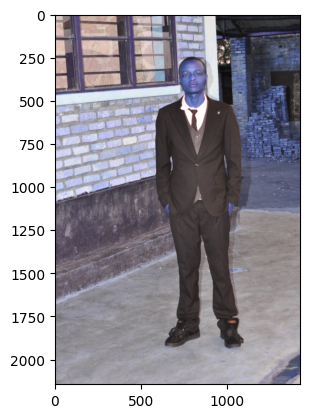

In [4]:
plt.imshow(img)

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape

(2144, 1424)

In [6]:
gray

array([[196, 201, 202, ...,  55,  53,  55],
       [197, 203, 204, ...,  54,  54,  55],
       [199, 203, 204, ...,  56,  55,  55],
       ...,
       [139, 140, 140, ..., 189, 189, 188],
       [141, 137, 138, ..., 193, 192, 190],
       [141, 139, 135, ..., 194, 194, 196]],
      shape=(2144, 1424), dtype=uint8)

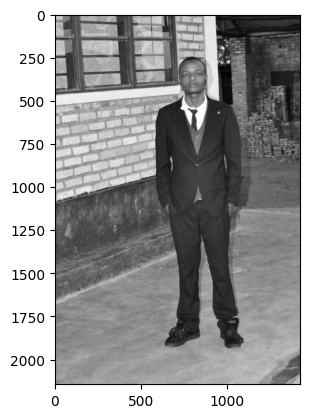

In [7]:
plt.imshow(gray, cmap='gray')

In [8]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades  + 'haarcascade_eye.xml'
)

print(face_cascade.empty())

faces  = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)
print(faces)

False
[[ 939  222   26   26]
 [ 720  290  160  160]
 [1250  517   30   30]
 [1058  653   50   50]
 [ 742  415  120  120]]


In [9]:
img.shape

(2144, 1424, 3)

In [10]:
messi = cv2.imread('../images_dataset/niyomugabo_etiene/DSC_0511.JPG')

messi.shape

(2144, 1424, 3)

In [11]:
grayMessi = cv2.cvtColor(messi, cv2.COLOR_BGR2GRAY)
grayMessi.shape

(2144, 1424)

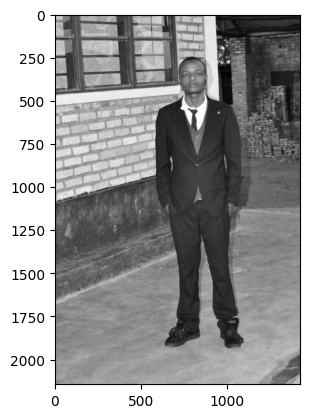

In [12]:
plt.imshow(grayMessi, cmap='gray')

In [13]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

print(face_cascade.empty())

faces  = face_cascade.detectMultiScale(grayMessi, scaleFactor=1.1, minNeighbors=4)
print(faces)

False
[[ 939  222   26   26]
 [ 720  290  160  160]
 [1250  517   30   30]
 [1058  653   50   50]
 [ 742  415  120  120]]


In [14]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(939), np.int32(222), np.int32(26), np.int32(26))

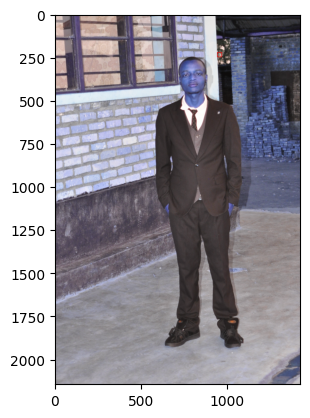

In [15]:
face_img = cv2.rectangle(messi, (x, y), (x+w, y+h), (255, 0, 0,), 2)
plt.imshow(face_img)

In [16]:
detect_eye = eye_cascade.detectMultiScale(grayMessi, 1.1, 4)
print(detect_eye)

[[ 807  327   42   42]
 [ 736  335   41   41]
 [1282  164   47   47]
 [ 767  427   80   80]]


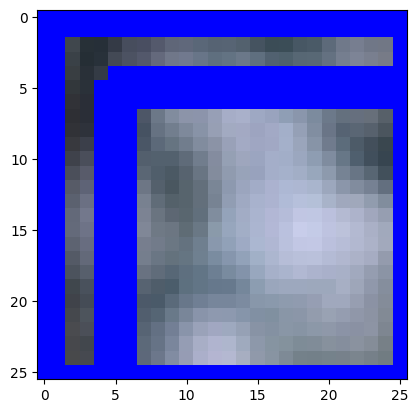

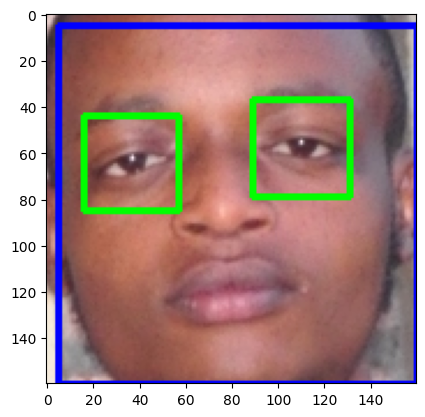

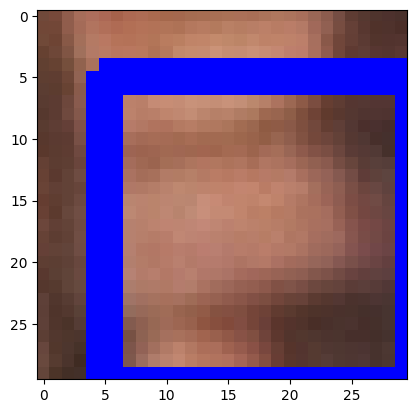

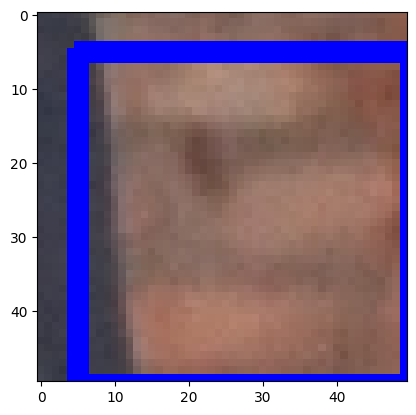

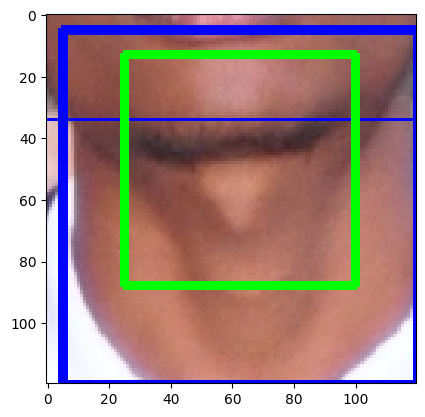

In [17]:
# crop each face
for (x, y, w, h) in faces:

    cropped_face = messi[y:y+h, x:x+w]

    cropped_gray = grayMessi[y:y+h, x:x+w]

    cv2.rectangle(
        cropped_face,
        (5, 5),
        (w, h),
        (255, 0, 0),
        2
    )

    eyes = eye_cascade.detectMultiScale(cropped_gray, 1.1, 4)

    for (ex, ey, ew, eh) in eyes:

        cv2.rectangle(
            cropped_face,
            (ex, ey),
            (ex+ew, ey+eh),
            (0,255,0),
            2
        )

    plt.imshow(cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB))
    plt.show()

In [18]:
def cropp_image_if_2_eyes(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=1)

    # print("Faces found:", len(faces))

    for (x, y, w, h) in faces:

        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray)

        # print("Eyes found:", len(eyes))

        if len(eyes) >= 2:
            return roi_color

    return None

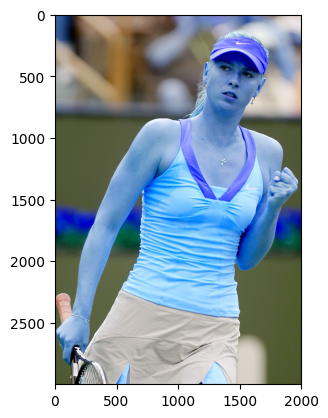

In [19]:
original_image = cv2.imread('../images_dataset/maria_sharapova/2-70.jpg')
plt.imshow(original_image)

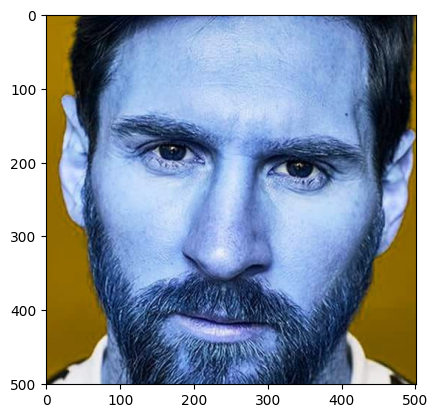

In [20]:
cropped_image = cropp_image_if_2_eyes('../images_dataset/lionel_messi/a8784d8ea286c3fbfef21201af1c1254.jpg')
plt.imshow(cropped_image)

In [21]:
path_to_data = '../images_dataset'
path_to_cr_data = '../images_dataset/cropped'

image_dirs = []

for entry in os.scandir(path_to_data):
    if entry.is_dir():
        image_dirs.append(entry.path)

In [22]:
image_dirs

['../images_dataset/serena_williams',
 '../images_dataset/bruce_molodie',
 '../images_dataset/element_elleh',
 '../images_dataset/juno_kizigenza',
 '../images_dataset/chriss_eazy',
 '../images_dataset/niyomugabo_etiene',
 '../images_dataset/maria_sharapova',
 '../images_dataset/cropped',
 '../images_dataset/virat_kohli',
 '../images_dataset/lionel_messi',
 '../images_dataset/roger_federer']

In [23]:
import shutil

if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)

os.mkdir(path_to_cr_data)

In [24]:
cropped_image_dirs = []
cerebilty_file_names_dict = {}

for image_dir in image_dirs:
    count = 1
    celebrity_name = image_dir.split('/')[-1]
    if celebrity_name == 'cropped':
        continue
    print(celebrity_name)
    cerebilty_file_names_dict[celebrity_name] = []

    for entry in os.scandir(image_dir):
        roi_color = cropp_image_if_2_eyes(entry.path)
        if roi_color is None:
            continue
        cropped_folder = path_to_cr_data + "/" + celebrity_name
        if not os.path.exists(cropped_folder):
            os.makedirs(cropped_folder)
            print('Generated cropped folder', cropped_folder)

        cropped_file_name = celebrity_name + str(count) + ".png"
        cropped_file_path = cropped_folder + "/" + cropped_file_name

        cv2.imwrite(cropped_file_path, roi_color)
        cerebilty_file_names_dict[celebrity_name].append(cropped_file_path)
        count += 1

serena_williams
Generated cropped folder ../images_dataset/cropped/serena_williams
bruce_molodie
Generated cropped folder ../images_dataset/cropped/bruce_molodie
element_elleh
Generated cropped folder ../images_dataset/cropped/element_elleh
juno_kizigenza
Generated cropped folder ../images_dataset/cropped/juno_kizigenza
chriss_eazy
Generated cropped folder ../images_dataset/cropped/chriss_eazy
niyomugabo_etiene
Generated cropped folder ../images_dataset/cropped/niyomugabo_etiene


Corrupt JPEG data: 5 extraneous bytes before marker 0xd9


maria_sharapova
Generated cropped folder ../images_dataset/cropped/maria_sharapova
virat_kohli
Generated cropped folder ../images_dataset/cropped/virat_kohli
lionel_messi
Generated cropped folder ../images_dataset/cropped/lionel_messi
roger_federer
Generated cropped folder ../images_dataset/cropped/roger_federer


In [25]:
import pywt

In [26]:
def w2d(img, mode='haar', level=1):
    imArray = img
    # convert to gray
    imArray = cv2.cvtColor(imArray, cv2.COLOR_RGB2GRAY)
    # convert to float
    imArray = np.float32(imArray)
    imArray /= 255 # normalize

    # compute coefficients (detect high-level frequencies and low-level frequencies)
    coeffs = pywt.wavedec2(imArray, mode, level=level)

    # process coefficients
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0 # remove low-level frequencies

    # reconstructions
    imArray_H = pywt.waverec2(coeffs_H, mode)
    imArray_H *= 255 # denormalize
    imArray_H = np.uint8(imArray_H) # convert back to number
    return imArray_H

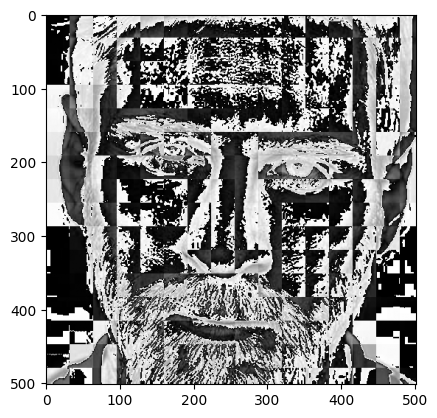

In [27]:
im_har = w2d(cropped_image, 'db1', 5)
plt.imshow(im_har, cmap='gray')

In [28]:
class_dict = {}
count = 0

for crebility_name, img in cerebilty_file_names_dict.items():
    class_dict[crebility_name] = count
    count += 1

class_dict

{'serena_williams': 0,
 'bruce_molodie': 1,
 'element_elleh': 2,
 'juno_kizigenza': 3,
 'chriss_eazy': 4,
 'niyomugabo_etiene': 5,
 'maria_sharapova': 6,
 'virat_kohli': 7,
 'lionel_messi': 8,
 'roger_federer': 9}

In [29]:
X = []
y = []

for crebility_name, training_files in cerebilty_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue

        scalled_img_raw = cv2.resize(img, (32, 32))
        img_haar = w2d(img, 'db1', 5)
        scalled_img_haar = cv2.resize(img_haar, (32, 32))
        combined_img = np.vstack((scalled_img_raw.reshape(32*32*3,1), scalled_img_haar.reshape(32*32, 1)))
        X.append(combined_img)
        y.append(class_dict[crebility_name])

[ WARN:0@347.192] global loadsave.cpp:278 findDecoder imread_('../images_dataset/cropped/niyomugabo_etiene/niyomugabo_etiene5.png'): can't open/read file: check file path/integrity
[ WARN:0@347.198] global loadsave.cpp:278 findDecoder imread_('../images_dataset/cropped/niyomugabo_etiene/niyomugabo_etiene7.png'): can't open/read file: check file path/integrity
[ WARN:0@347.201] global loadsave.cpp:278 findDecoder imread_('../images_dataset/cropped/niyomugabo_etiene/niyomugabo_etiene9.png'): can't open/read file: check file path/integrity


In [30]:
len(X)

273

In [31]:
len(X[0])

4096

In [32]:
X = np.array(X).reshape(len(X), 4096).astype(float)
X.shape

(273, 4096)

In [33]:
X[0]

array([  1.,   1.,   1., ..., 245., 140.,  87.], shape=(4096,))

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=10))
])

pipe.fit(X_train, y_train)

pipe.score(X_test, y_test)

0.5507246376811594

In [36]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.33      0.67      0.44         9
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         3
           4       0.50      0.33      0.40         3
           5       0.00      0.00      0.00         1
           6       0.55      0.92      0.69        12
           7       0.58      0.58      0.58        12
           8       1.00      0.41      0.58        17
           9       0.60      0.67      0.63         9

    accuracy                           0.55        69
   macro avg       0.36      0.36      0.33        69
weighted avg       0.59      0.55      0.52        69



/home/etiene-niyomugabo123/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/etiene-niyomugabo123/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/etiene-niyomugabo123/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [ ]:
from sklearn import svm
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [ ]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto', probability=True),
        'params': {
            'svc__C': [1, 10, 100, 1000],
            'svc__kernel': ['rbf', 'linear']
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params': {
            'randomforestclassifier__n_estimators': [1, 5, 10]
        }
    },
    'logistic_regression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'logisticregression__C': [1, 5, 10]
        }
    }
}

In [ ]:
scores = []
best_estimators = {}
import pandas as pd

for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf = GridSearchCV(pipe, mp['params'], cv=5, return_train_score=True)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_

df = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
df

In [ ]:
best_estimators

In [ ]:
best_estimators['svm'].score(X_test, y_test)

In [ ]:
best_estimators['random_forest'].score(X_test, y_test)

In [ ]:
best_estimators['logistic_regression'].score(X_test, y_test)

In [ ]:
best_clf = best_estimators['logistic_regression']

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

In [ ]:
import seaborn as sns

plt.figure(figsize = (10, 7))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
class_dict

In [49]:
import joblib

In [50]:
joblib.dump(best_clf, 'saved_model.pkl')

['saved_model.pkl']

In [51]:
import json

with open('class_dictonary.json', 'w') as f:
    f.write(json.dumps(class_dict))